# 02 — Caracterização da população

## 1. Objetivo

Descrever as características sociodemográficas, clínicas, antropométricas e metabólicas dos pacientes válidos. Todas as doenças são mantidas em uma única coorte; o diagnóstico é usado somente de forma descritiva. Nenhum teste inferencial é realizado.

Campos clínicos livres ou sem unidade padronizada não são convertidos em medidas clínicas por inferência. Categorias ocupacionais raras são agrupadas para reduzir risco de reidentificação.

## 2. Importações

In [1]:
from hashlib import sha256
from pathlib import Path
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 3. Configuração

In [2]:
RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "processed" / "pacientes_clean.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.cleaning import clean_text_column
from src.plots import plot_variable_availability, save_figure
from src.statistics import descriptive_categorical, descriptive_numeric

PROCESSED_PATH = PROJECT_ROOT / "data" / "processed" / "pacientes_clean.csv"
RAW_PATH = PROJECT_ROOT / "data" / "raw" / "sociodemografico.csv"
TABLE_PATH = PROJECT_ROOT / "outputs" / "tables" / "table_1_population.csv"
AVAILABILITY_FIGURE_PATH = PROJECT_ROOT / "outputs" / "figures" / "population_variable_availability.png"
EXPECTED_RAW_SHA256 = "a895b5340c856d2cd1772c8e115ed5efc20f409d3aef5ecba14da23d44da9bf4"

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}")

Python: 3.14.6
pandas: 3.0.5


## 4. Carregamento

Somente o dataset anonimizado é carregado para análise. Nenhuma linha individual é exibida.

In [3]:
df = pd.read_csv(PROCESSED_PATH)
print(f"Dimensão do dataset processado: {df.shape[0]} linhas × {df.shape[1]} colunas")
print(f"Pacientes com identificador interno válido: {df['patient_id'].notna().sum()}")

Dimensão do dataset processado: 75 linhas × 38 colunas
Pacientes com identificador interno válido: 75


## 5. Validações

In [4]:
required_columns = {
    "patient_id", "estado_civil", "escolaridade", "ocupacao",
    "renda_mensal_familiar", "diagnostico_padronizado",
    "tempo_diagnostico", "uso_corticoide", "uso_imunobiologico",
    "comorbidade_medicamento", "tabagismo", "etilismo",
    "atividade_fisica", "imc", "circunferencia_abdominal",
    "circunferencia_cervical", "findrisc_score",
}
assert required_columns.issubset(df.columns)
assert len(df) == df["patient_id"].nunique()
assert df["patient_id"].notna().all()
assert "nome" not in df.columns and "Cod" not in df.columns
assert sha256(RAW_PATH.read_bytes()).hexdigest() == EXPECTED_RAW_SHA256
print("Dataset anonimizado e esquema analítico validados.")

Dataset anonimizado e esquema analítico validados.


## 6. Análise descritiva

### 6.1 Preparação conservadora dos campos clínicos

Respostas livres não são interpretadas como exposição clínica. Valores explicitamente `Sim` ou `Não` são mantidos; os demais são marcados como resposta detalhada não padronizada. Missing permanece missing.

In [5]:
def conservative_response(series):
    cleaned = clean_text_column(series)
    result = pd.Series(pd.NA, index=series.index, dtype="string")
    result.loc[cleaned.eq("Sim")] = "Sim"
    result.loc[cleaned.eq("Não")] = "Não"
    detailed = cleaned.notna() & ~cleaned.isin(["Sim", "Não"])
    result.loc[detailed] = "Resposta detalhada/não padronizada"
    return result

def information_recorded(series):
    cleaned = clean_text_column(series)
    result = pd.Series(pd.NA, index=series.index, dtype="string")
    result.loc[cleaned.notna()] = "Informação registrada"
    return result

def boolean_labels(series):
    result = pd.Series(pd.NA, index=series.index, dtype="string")
    result.loc[series.eq(True)] = "Sim"
    result.loc[series.eq(False)] = "Não"
    return result

clinical_summaries = {
    "uso_corticoide": boolean_labels(df["uso_corticoide"]),
    "uso_imunobiologico": conservative_response(df["uso_imunobiologico"]),
    "tabagismo": conservative_response(df["tabagismo"]),
    "etilismo": conservative_response(df["etilismo"]),
    "atividade_fisica": conservative_response(df["atividade_fisica"]),
    "tempo_diagnostico": information_recorded(df["tempo_diagnostico"]),
    "comorbidade_medicamento": information_recorded(df["comorbidade_medicamento"]),
}

### 6.2 Variáveis quantitativas

In [6]:
TABLE_COLUMNS = [
    "secao", "variavel", "categoria", "n_valido", "n_ausente",
    "n", "percentual", "media", "moda", "desvio_padrao",
    "mediana", "p25", "p75", "minimo", "maximo", "observacoes",
]
quantitative_specs = [
    ("Antropométricas", "IMC (kg/m²)", "imc", "Nenhum valor extremo foi excluído."),
    ("Antropométricas", "Circunferência abdominal (cm)", "circunferencia_abdominal", ""),
    ("Antropométricas", "Circunferência cervical (cm)", "circunferencia_cervical", "Valor máximo requer conferência; nenhum valor foi excluído."),
    ("Metabólicas", "FINDRISC (pontos)", "findrisc_score", "Categoria recalculada exclusivamente pela pontuação."),
]
numeric_rows = []
for section, label, column, note in quantitative_specs:
    summary = descriptive_numeric(df[column])
    observations = " ".join(filter(None, [summary.pop("observacoes"), note]))
    numeric_rows.append({
        "secao": section,
        "variavel": label,
        "categoria": "Resumo quantitativo",
        "n": np.nan,
        "percentual": np.nan,
        **summary,
        "observacoes": observations,
    })

numeric_table = pd.DataFrame(numeric_rows)[TABLE_COLUMNS]
numeric_columns_to_round = [
    "media", "desvio_padrao", "mediana", "p25", "p75", "minimo", "maximo",
]
numeric_table[numeric_columns_to_round] = numeric_table[numeric_columns_to_round].round(2)
display(numeric_table)

,secao,variavel,categoria,n_valido,n_ausente,n,percentual,media,moda,desvio_padrao,mediana,p25,p75,minimo,maximo,observacoes
0,Antropométricas,IMC (kg/m²),Resumo quantitativo,73,2,NaN,NaN,28.72,29,5.50,27.94,24.62,32.3,17.5,41.1,Nenhum valor extremo foi excluído.
1,Antropométricas,Circunferência abdominal (cm),Resumo quantitativo,73,2,NaN,NaN,94.97,79; 98; 108,12.18,96.00,86.00,104.0,71.0,126.0,Distribuição multimodal (3 modas).
2,Antropométricas,Circunferência cervical (cm),Resumo quantitativo,75,0,NaN,NaN,37.36,35,9.21,36.00,34.00,39.0,30.0,110.0,Valor máximo requer conferência; nenhum valor ...
3,Metabólicas,FINDRISC (pontos),Resumo quantitativo,74,1,NaN,NaN,13.76,9,6.25,14.00,9.00,19.0,2.0,24.0,Categoria recalculada exclusivamente pela pont...


### 6.3 Variáveis categóricas

Cada percentual usa o número de respostas válidas da própria variável. Missing é registrado separadamente e não entra no denominador.

In [7]:
categorical_specs = [
    ("Sociodemográficas", "Estado civil", df["estado_civil"], {}, ""),
    ("Sociodemográficas", "Escolaridade", df["escolaridade"], {}, ""),
    ("Sociodemográficas", "Renda mensal familiar", df["renda_mensal_familiar"], {}, ""),
    ("Sociodemográficas", "Ocupação", df["ocupacao"], {"min_count": 3, "other_label": "Outras ocupações", "case_sensitive": False}, "Categorias com n<3 agrupadas por privacidade."),
    ("Clínicas", "Diagnóstico", df["diagnostico_padronizado"], {}, "Uso exclusivamente descritivo; diagnósticos múltiplos preservados."),
    ("Clínicas", "Tempo de doença", clinical_summaries["tempo_diagnostico"], {}, "Campo heterogêneo, sem unidade padronizada; não resumido quantitativamente."),
    ("Clínicas", "Uso de corticoide", clinical_summaries["uso_corticoide"], {}, ""),
    ("Clínicas", "Uso de imunobiológico", clinical_summaries["uso_imunobiologico"], {}, "Somente respostas explícitas Sim/Não foram categorizadas."),
    ("Clínicas", "Comorbidades/medicamentos", clinical_summaries["comorbidade_medicamento"], {}, "Campo livre; frequência de condições específicas não inferida."),
    ("Clínicas", "Tabagismo", clinical_summaries["tabagismo"], {}, "Campo mistura estado atual e histórico."),
    ("Clínicas", "Etilismo", clinical_summaries["etilismo"], {}, "Campo mistura estado atual, frequência e histórico."),
    ("Clínicas", "Atividade física", clinical_summaries["atividade_fisica"], {}, "Campo mistura estado, modalidade, frequência e duração."),
    ("Antropométricas", "Categoria de IMC", df["imc_categoria"], {}, ""),
    ("Metabólicas", "Categoria FINDRISC", df["findrisc_categoria"], {}, "Classificação recalculada pela pontuação."),
]
categorical_tables = []
for section, label, series, options, note in categorical_specs:
    summary = descriptive_categorical(series, **options)
    summary.insert(0, "variavel", label)
    summary.insert(0, "secao", section)
    summary["media"] = np.nan
    summary["moda"] = pd.NA
    summary["desvio_padrao"] = np.nan
    summary["mediana"] = np.nan
    summary["p25"] = np.nan
    summary["p75"] = np.nan
    summary["minimo"] = np.nan
    summary["maximo"] = np.nan
    summary["observacoes"] = note
    categorical_tables.append(summary[TABLE_COLUMNS])

categorical_table = pd.concat(categorical_tables, ignore_index=True)
table_1 = pd.concat([categorical_table, numeric_table], ignore_index=True)
display(table_1)

,secao,variavel,categoria,n_valido,n_ausente,n,percentual,media,moda,desvio_padrao,mediana,p25,p75,minimo,maximo,observacoes
0,Sociodemográficas,Estado civil,Solteiro,75,0,38.0,50.67,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,
1,Sociodemográficas,Estado civil,Casado,75,0,26.0,34.67,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,
2,Sociodemográficas,Estado civil,Viúvo,75,0,6.0,8.0,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,
3,Sociodemográficas,Estado civil,Divorciado,75,0,5.0,6.67,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,
4,Sociodemográficas,Escolaridade,Ensino fundamental incompleto,75,0,21.0,28.0,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,Metabólicas,Categoria FINDRISC,Baixo risco,74,1,10.0,13.51,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,Classificação recalculada pela pontuação.
60,Antropométricas,IMC (kg/m²),Resumo quantitativo,73,2,<NA>,<NA>,28.72,29,5.50,27.94,24.62,32.3,17.5,41.1,Nenhum valor extremo foi excluído.
61,Antropométricas,Circunferência abdominal (cm),Resumo quantitativo,73,2,<NA>,<NA>,94.97,79; 98; 108,12.18,96.00,86.00,104.0,71.0,126.0,Distribuição multimodal (3 modas).
62,Antropométricas,Circunferência cervical (cm),Resumo quantitativo,75,0,<NA>,<NA>,37.36,35,9.21,36.00,34.00,39.0,30.0,110.0,Valor máximo requer conferência; nenhum valor ...


## 7. Visualização

A visualização resume a disponibilidade das variáveis centrais, sem apresentar dados individuais.

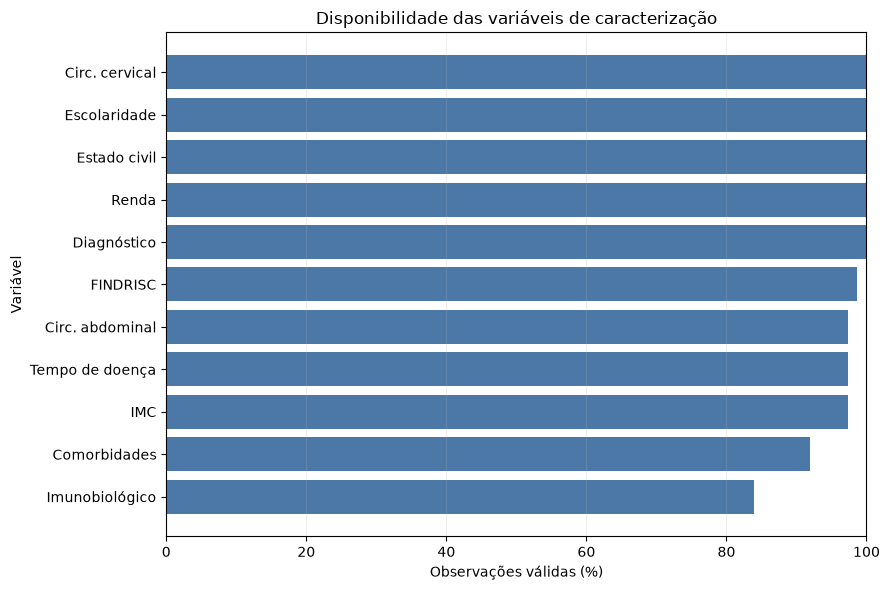

In [8]:
availability_columns = {
    "Estado civil": "estado_civil",
    "Escolaridade": "escolaridade",
    "Renda": "renda_mensal_familiar",
    "Diagnóstico": "diagnostico_padronizado",
    "Tempo de doença": "tempo_diagnostico",
    "Imunobiológico": "uso_imunobiologico",
    "Comorbidades": "comorbidade_medicamento",
    "IMC": "imc",
    "Circ. abdominal": "circunferencia_abdominal",
    "Circ. cervical": "circunferencia_cervical",
    "FINDRISC": "findrisc_score",
}
availability = pd.Series({
    label: 100 * df[column].notna().sum() / len(df)
    for label, column in availability_columns.items()
}).sort_values()
figure, _ = plot_variable_availability(availability)
save_figure(figure, AVAILABILITY_FIGURE_PATH)
plt.show()

## 8. Conclusões deste notebook

In [9]:
for variable, rows in categorical_table.groupby("variavel"):
    assert rows["n"].sum() == rows["n_valido"].iloc[0], variable
    assert abs(rows["percentual"].sum() - 100) < 0.05, variable

print(f"Amostra descrita: {len(df)} pacientes")
print("Percentuais categóricos calculados com denominador válido por variável.")
print("Tempo de doença não resumido quantitativamente: campo sem unidade padronizada.")
print("Diagnósticos apresentados descritivamente; a análise principal mantém coorte única.")
print("Nenhum teste inferencial foi realizado.")

Amostra descrita: 75 pacientes
Percentuais categóricos calculados com denominador válido por variável.
Tempo de doença não resumido quantitativamente: campo sem unidade padronizada.
Diagnósticos apresentados descritivamente; a análise principal mantém coorte única.
Nenhum teste inferencial foi realizado.


## 9. Output gerado

In [10]:
TABLE_PATH.parent.mkdir(parents=True, exist_ok=True)
table_1.to_csv(TABLE_PATH, index=False, encoding="utf-8")

reloaded = pd.read_csv(TABLE_PATH)
assert reloaded.columns.tolist() == TABLE_COLUMNS
assert not reloaded.astype("string").apply(
    lambda column: column.str.fullmatch(r"P\d{3}")
).any().any()
assert sha256(RAW_PATH.read_bytes()).hexdigest() == EXPECTED_RAW_SHA256
print(TABLE_PATH.relative_to(PROJECT_ROOT))

outputs/tables/table_1_population.csv
